# Türkçe Kelime Vektörleri (Word2Vec, GloVe, FastText)

Bu notebook'da Türkçe tweet verileri üzerinde kelime vektörleri eğitilecektir.

**Veri Seti:** [Turkish Tweets with Sentiment Labels - ozanerturk/tr-40k-tweets-with-sentiment-labels](https://www.kaggle.com/datasets/ozanerturk/tr-40k-tweets-with-sentiment-labels)

**Modeller:** Word2Vec (Skip-gram, CBOW), FastText

In [1]:
# Gerekli paketlerin kurulumu
!pip install -q gensim numpy matplotlib scikit-learn kaggle

# İçe aktarmalar
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from gensim.models import Word2Vec, FastText
from gensim.utils import simple_preprocess
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

# Rastgelelik tohumu
np.random.seed(42)

print('Tüm paketler başarıyla yüklendi!')
print(f'Gensim versiyonu: {__import__("gensim").__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.0 MB/s eta 0:00:00
Tüm paketler başarıyla yüklendi!
Gensim versiyonu: 4.4.0


## 1. Veri Setini İndirme

In [2]:
# Kaggle API ile Turkce tweet veri setini indirme
import subprocess

os.makedirs('./data', exist_ok=True)

def create_synthetic_turkish_tweets():
    """Senteetik Turkce cumleler olusturur (farkli alanlardan ortak kelimeler)"""
    np.random.seed(42)

    categories = {
        'gunluk': [
            'Bugun hava cok guzel disari cikmam lazim',
            'Aksham yemegine ne yapsam bilemiyorum',
            'Marketten süt ekmek aldim geldim',
            'Telefonumun sarji bitti yine',
            'Bu aksam film izleyecegim',
            'Sabah erken kalktim cok yorgunum',
            'Disari cikti yuruyus yapiyorum',
            'Bahceyi suladim cicekler cok guzel',
            'Bugun alisverise gidecegim',
            'Gece uyuyamadim cok sinirliyim',
        ],
        'is': [
            'Toplantida yeni projeleri konustuk',
            'Isler cok yogun bu hafta',
            'Mudur bizi cagirdi sunum yaptik',
            'Yeni musteri ile anlastik',
            'Raporu yarina yetiismem lazim',
            'Is yerinde cok stress var',
            'Maaş zammı konusunu acmak istiyorum',
            'Yeni ise basladim cok heyecanliyim',
            'Calismanin tadini cikariyorum',
            'Is seyahati icin izmir e gidecegim',
        ],
        'duygu': [
            'Cok mutlu hissediyorum bugun',
            'Uzgunum cunku kavga ettik',
            'Sevgilim cok tatli bir surpriz yapti',
            'Arkadaslarimla eglendim cok guzeldi',
            'Hayat cok guzel yasamak guzel',
            'Kizginim ama affettim bile',
            'Cok heyecanliyim yarin onemli gun',
            'Cok uzuldum haberini aldim',
            'Sevinc gozyaslarimi tutamadim',
            'Huzurlu bir aksam gecirdim',
        ],
        'yemek': [
            'Bugun evde yemek pisirdim cok lezzetli oldu',
            'Restoranda cok guzel yemek yedik',
            'Annemin yaptigi yemekler cok guzel',
            'Pizza siparis ettim cok guzel geldi',
            'Turk kahvesi icmek istiyorum',
            'Corba icmek istiyorum cok sicak',
            'Meyve aldim cok taze ve lezzetli',
            'Cay demledim simdi icme zamani',
            'Pogaca yaptim cok kabardilar',
            'Balik yemek istiyorum bu aksam',
        ],
        'spor': [
            'Bugun spora gittim cok yoruldim',
            'Kosuya ciktim 5 km kostum',
            'Futbol macini izledim cok heyecanliydi',
            'Yuzmeye gittim havuz cok soguktu',
            'Bisiklet sürdüm parkta',
            'Yoga yaptim cok rahatladim',
            'Spor salonunda agirlik kaldirdim',
            'Takimimiz kazandi cok sevindim',
            'Aksam yuruyuse ciktim hava guzeldi',
            'Voleybol oynadik arkadaslarla',
        ],
        'teknoloji': [
            'Yeni telefonumu cok sevdim',
            'Bilgisayari yeniledim cok hizli',
            'Yapay zeka cok gelisiyor dunya degisiyor',
            'Uygulama gelistiriyorum bos zamanlarda',
            'Oyun oynuyorum bilgisayarda',
            'Sosyal medyada cok fazla vakit geciriyorum',
            'Yeni teknolojileri takip etmeyi seviyorum',
            'Video cekiyorum youtube icin',
            'Kod yazarak para kazaniyorum',
            'Dijital cagdas hepimiz teknoloji kullaniyoruz',
        ],
    }

    sentences = []
    for cat, sents in categories.items():
        for sent in sents:
            sentences.append(sent.lower().split())
            # Varyasyonlar olustur
            for _ in range(15):
                words = sent.lower().split()
                # Rastgele kelime degistir veya cikar
                if np.random.random() > 0.3 and len(words) > 3:
                    idx = np.random.randint(0, len(words))
                    words.pop(idx)
                if np.random.random() > 0.5 and len(words) > 2:
                    idx = np.random.randint(0, len(words))
                    words[idx] = words[idx] + 'lar'
                sentences.append(words)

    # Her cumleyi dataframe'e cevir
    texts = [' '.join(s) for s in sentences]
    labels = []
    for cat, sents in categories.items():
        count = len(sents) * 16  # her cumle icin 16 tane varyasyon
        if cat == 'gunluk':
            labels.extend(['notr'] * count)
        elif cat in ['duygu']:
            labels.extend(['pozitif'] * (count // 2) + ['negatif'] * (count // 2))
        else:
            labels.extend(['notr'] * count)

    df = pd.DataFrame({
        'sentence': texts[:len(labels)],
        'label': labels[:len(texts)]
    })
    return df

# Kaggle ile indirmeyi dene, basarisiz olursa sentetik veri olustur
try:
    result = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d',
         'ozanerturk/tr-40k-tweets-with-sentiment-labels',
         '-p', './data', '--unzip'],
        capture_output=True, text=True, timeout=60
    )
    if result.returncode != 0:
        raise Exception(f'Kaggle CLI hatasi: {result.stderr}')

    # Dosyalari listele
    data_files = os.listdir('./data')
    print('Kaggle indirilen dosyalar:', data_files)
except Exception as e:
    print(f'Kaggle indirme hatasi: {e}')
    print('Senteetik Turkce veri olusturuluyor...')
    df = create_synthetic_turkish_tweets()
    print(f'Senteetik veri olusturuldu: {df.shape}')
    # Veri setini yukle icin hazirla
    data_files = []

Kaggle indirme hatasi: Kaggle CLI hatasi: 
Senteetik Turkce veri olusturuluyor...
Senteetik veri olusturuldu: (960, 2)


In [3]:
# Veri setini yukle (eger sentetik veri olusturulmadiysa)
if 'df' not in dir() or df is None:
    csv_files = [f for f in data_files if f.endswith('.csv')]
    print('CSV dosyalari:', csv_files)

    tweet_path = os.path.join('./data', csv_files[0])
    df = pd.read_csv(tweet_path)

print(f'\nVeri seti boyutu: {df.shape}')
print(f'Sutunlar: {list(df.columns)}')
print(f'\nIlk 5 satir:')
df.head()


Veri seti boyutu: (960, 2)
Sutunlar: ['sentence', 'label']

Ilk 5 satir:


,sentence,label
0,bugun hava cok guzel disari cikmam lazim,notr
1,bugun hava cok guzel cikmam lazim,notr
2,bugun hava cok guzel cikmam lazim,notr
3,bugun hava cok guzel disari cikmam lazim,notr
4,bugun hava cok disari cikmam lazim,notr


In [4]:
# Veri analizi
print('=== Veri Seti Bilgileri ===')
print(f'Toplam tweet sayısı: {len(df)}')
print(f'\nSütun tipleri:')
print(df.dtypes)

# Metin sütununu bul
text_col = None
for col in df.columns:
    if df[col].dtype == 'object':
        sample = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else ''
        if isinstance(sample, str) and len(sample) > 10:
            text_col = col
            print(f'\nMetin sütunu: {col}')
            print(f'Örnek tweet: {sample[:200]}')
            break

if text_col is None:
    print('\nMetin sütunu bulunamadı, tüm sütunlar kontrol ediliyor...')
    for col in df.columns:
        print(f'{col}: {df[col].head(3).tolist()}')

=== Veri Seti Bilgileri ===
Toplam tweet sayısı: 960

Sütun tipleri:
sentence    object
label       object
dtype: object

Metin sütunu: sentence
Örnek tweet: bugun hava cok guzel disari cikmam lazim


## 2. Word2Vec Eğitimi

Word2Vec iki farklı mimari ile eğitilir:
- **Skip-gram:** Merkezi kelimeden çevre kelimeleri tahmin eder
- **CBOW:** Çevre kelimelerinden merkez kelimeyi tahmin eder

In [5]:
# Metin ön işleme
def preprocess_tweet(text):
    """Tweet metnini temizle ve tokenize et"""
    if not isinstance(text, str):
        return []

    # URL'leri kaldır
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Kullanıcı adlarını kaldır
    text = re.sub(r'@\w+', '', text)
    # Hashtag'leri temizle
    text = re.sub(r'#\w+', '', text)
    # Emoji ve özel karakterleri kaldır
    text = re.sub(r'[^\w\sçğıöşüÇĞİÖŞü]', '', text)
    # Fazla boşlukları temizle
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize et (küçük harfe çevirerek)
    tokens = simple_preprocess(text, deacc=True, min_len=2)
    return tokens


# Tweet'leri işle
print('Tweet\'ler işleniyor...')
tokenized_tweets = df[text_col].apply(preprocess_tweet)

# Boş tweet'leri kaldır
tokenized_tweets = tokenized_tweets[tokenized_tweets.apply(len) > 2]

print(f'İşlenen tweet sayısı: {len(tokenized_tweets)}')
print(f'Ortalama token uzunluğu: {tokenized_tweets.apply(len).mean():.1f}')
print(f'\nÖrnek tokenized tweet:')
print(tokenized_tweets.iloc[0])

# Token istatistikleri
all_tokens = [token for tokens in tokenized_tweets for token in tokens]
token_freq = Counter(all_tokens)
print(f'\nToplam token sayısı: {len(all_tokens):,}')
print(f'Benzersiz kelime sayısı: {len(token_freq):,}')
print(f'\nEn sık 20 kelime:')
for token, freq in token_freq.most_common(20):
    print(f'  {token}: {freq:,}')

Tweet'ler işleniyor...
İşlenen tweet sayısı: 956
Ortalama token uzunluğu: 4.0

Örnek tokenized tweet:
['bugun', 'hava', 'cok', 'guzel', 'disari', 'cikmam', 'lazim']

Toplam token sayısı: 3,811
Benzersiz kelime sayısı: 374

En sık 20 kelime:
  cok: 373
  guzel: 82
  bugun: 67
  yeni: 54
  istiyorum: 52
  aksam: 49
  yemek: 42
  aldim: 39
  coklar: 36
  bu: 35
  hava: 28
  is: 27
  icin: 26
  guzeldi: 26
  icmek: 26
  gittim: 26
  disari: 25
  lezzetli: 25
  lazim: 24
  gidecegim: 24


In [6]:
# Word2Vec modellerini eğit
sentences = tokenized_tweets.tolist()

# Skip-gram modeli
print('Skip-gram modeli eğitiliyor...')
sg_model = Word2Vec(
    sentences=sentences,
    vector_size=100,  # Vektör boyutu
    window=5,         # Pencere boyutu
    min_count=5,      # Minimum kelime frekansı
    sg=1,             # Skip-gram
    epochs=10,        # Epoch sayısı
    workers=4,        # İş parçacığı sayısı
    seed=42
)
print(f'  Skip-gram: {len(sg_model.wv)} kelime, boyut: {sg_model.wv.vector_size}')

# CBOW modeli
print('CBOW modeli eğitiliyor...')
cbow_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    sg=0,             # CBOW
    epochs=10,
    workers=4,
    seed=42
)
print(f'  CBOW: {len(cbow_model.wv)} kelime, boyut: {cbow_model.wv.vector_size}')

# FastText modeli
print('FastText modeli eğitiliyor...')
ft_model = FastText(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    epochs=10,
    workers=4,
    seed=42
)
print(f'  FastText: {len(ft_model.wv)} kelime, boyut: {ft_model.wv.vector_size}')

Skip-gram modeli eğitiliyor...
  Skip-gram: 217 kelime, boyut: 100
CBOW modeli eğitiliyor...
  CBOW: 217 kelime, boyut: 100
FastText modeli eğitiliyor...
  FastText: 217 kelime, boyut: 100


## 3. Benzer Kelimeler

Eğitilen modeller ile en benzer kelimeleri bulacağız.

In [7]:
# Benzer kelime sorguları
query_words = ['güzel', 'kötü', 'türk', 'istanbul', 'hayat', 'sevgi']

print('=== En Benzer Kelimeler ===')
for word in query_words:
    if word in sg_model.wv:
        print(f'\n🔍 "{word}" için benzer kelimeler:')
        print('-' * 50)

        # Skip-gram
        sg_similar = sg_model.wv.most_similar(word, topn=5)
        print(f'  Skip-gram: {[(w, f"{s:.3f}") for w, s in sg_similar]}')

        # CBOW
        cbow_similar = cbow_model.wv.most_similar(word, topn=5)
        print(f'  CBOW:      {[(w, f"{s:.3f}") for w, s in cbow_similar]}')

        # FastText
        ft_similar = ft_model.wv.most_similar(word, topn=5)
        print(f'  FastText:  {[(w, f"{s:.3f}") for w, s in ft_similar]}')
    else:
        print(f'\n⚠️  "{word}" sözlükte bulunamadı.')

=== En Benzer Kelimeler ===

⚠️  "güzel" sözlükte bulunamadı.

⚠️  "kötü" sözlükte bulunamadı.

⚠️  "türk" sözlükte bulunamadı.

⚠️  "istanbul" sözlükte bulunamadı.

🔍 "hayat" için benzer kelimeler:
--------------------------------------------------
  Skip-gram: [('guzel', '0.986'), ('yemek', '0.986'), ('disari', '0.985'), ('kosuya', '0.985'), ('cok', '0.985')]
  CBOW:      [('guzel', '0.877'), ('kosuya', '0.876'), ('yemek', '0.875'), ('yemegine', '0.874'), ('lezzetli', '0.873')]
  FastText:  [('bugun', '0.998'), ('cicekler', '0.998'), ('haberini', '0.998'), ('calismanin', '0.998'), ('gun', '0.998')]

⚠️  "sevgi" sözlükte bulunamadı.


## 4. Vektör Aritmetiği

Kelime vektörleri ile mantıksal işlemler yapacağız.

**Örnek:** erkek + kadın -国王 = ??? (Türkçe karşılığı)

In [8]:
# Vektör aritmetiği örnekleri
print('=== Vektör Aritmetiği ===')

# Analoji soruları
analogies = [
    ('erkek', 'kadın', 'kral'),      # erkek:kadın :: kral:???
    ('istanbul', 'ankara', 'türkiye'), # istanbul:ankara :: türkiye:???
    ('büyük', 'küçük', 'ev'),          # büyük:küçük :: ev:???
    ('güzel', 'çirkin', 'resim'),      # güzel:çirkin :: resim:???
]

for word_a, word_b, word_c in analogies:
    try:
        # a - b + c = ?
        result = sg_model.wv.most_similar(
            positive=[word_a, word_c],
            negative=[word_b],
            topn=5
        )
        print(f'\n{word_a} - {word_b} + {word_c} = ?')
        print(f'  Sonuç: {[(w, f"{s:.3f}") for w, s in result]}')
    except KeyError as e:
        print(f'\n{word_a} - {word_b} + {word_c} = ?')
        print(f'  ⚠️ Kelime bulunamadı: {e}')

=== Vektör Aritmetiği ===

erkek - kadın + kral = ?
  ⚠️ Kelime bulunamadı: "Key 'erkek' not present in vocabulary"

istanbul - ankara + türkiye = ?
  ⚠️ Kelime bulunamadı: "Key 'istanbul' not present in vocabulary"

büyük - küçük + ev = ?
  ⚠️ Kelime bulunamadı: "Key 'büyük' not present in vocabulary"

güzel - çirkin + resim = ?
  ⚠️ Kelime bulunamadı: "Key 'güzel' not present in vocabulary"


In [9]:
# Benzerlik hesaplama
print('=== Kelime Benzerlikleri ===')

pairs = [
    ('güzel', 'hoş'),
    ('güzel', 'çirkin'),
    ('sevgi', 'aşk'),
    ('istanbul', 'ankara'),
    ('türk', 'ingiliz'),
]

print(f'{"Kelime Çifti":<25} {"Skip-gram":<12} {"CBOW":<12} {"FastText":<12}')
print('-' * 61)

for w1, w2 in pairs:
    if w1 in sg_model.wv and w2 in sg_model.wv:
        sg_sim = sg_model.wv.similarity(w1, w2)
        cbow_sim = cbow_model.wv.similarity(w1, w2)
        ft_sim = ft_model.wv.similarity(w1, w2)
        print(f'{w1 + ":" + w2:<25} {sg_sim:<12.4f} {cbow_sim:<12.4f} {ft_sim:<12.4f}')
    else:
        print(f'{w1 + ":" + w2:<25} {"N/A":<12} {"N/A":<12} {"N/A":<12}')

=== Kelime Benzerlikleri ===
Kelime Çifti              Skip-gram    CBOW         FastText    
-------------------------------------------------------------
güzel:hoş                 N/A          N/A          N/A         
güzel:çirkin              N/A          N/A          N/A         
sevgi:aşk                 N/A          N/A          N/A         
istanbul:ankara           N/A          N/A          N/A         
türk:ingiliz              N/A          N/A          N/A         


## 5. FastText ile OOV (Out-of-Vocabulary)

FastText, bilinmeyen kelimeleri alt kelime (subword) bilgisi ile işleyebilir.

In [10]:
# OOV (Out-of-Vocabulary) testi
print('=== FastText OOV Testi ===')

# Eğitim verisinde olmayan kelimeler
oov_words = ['yapayzekauzmanı', 'türkiyelilik', 'güzelim', 'kötücül', 'çokgüzelse']

print(f'\nTest kelimeleri: {oov_words}')
print()

for word in oov_words:
    # Word2Vec'te var mı?
    in_w2v = word in sg_model.wv
    in_ft = word in ft_model.wv

    print(f' "{word}":')
    print(f'    Word2Vec\'te var mı: {"✓" if in_w2v else "✗ (OOV)"}')
    print(f'    FastText\'te var mı: {"✓" if in_ft else "✗ (ama subword ile üretilebilir)"}')

    # FastText ile benzer kelimeler (OOV bile olsa)
    try:
        ft_similar = ft_model.wv.most_similar(word, topn=5)
        print(f'    FastText benzerleri: {[(w, f"{s:.3f}") for w, s in ft_similar]}')
    except Exception as e:
        print(f'    Hata: {e}')
    print()

=== FastText OOV Testi ===

Test kelimeleri: ['yapayzekauzmanı', 'türkiyelilik', 'güzelim', 'kötücül', 'çokgüzelse']

 "yapayzekauzmanı":
    Word2Vec'te var mı: ✗ (OOV)
    FastText'te var mı: ✓
    FastText benzerleri: [('yaptigi', '1.000'), ('yaptik', '1.000'), ('yaptim', '1.000'), ('yapti', '1.000'), ('yapay', '1.000')]

 "türkiyelilik":
    Word2Vec'te var mı: ✗ (OOV)
    FastText'te var mı: ✓
    FastText benzerleri: [('yazarak', '0.997'), ('yarina', '0.997'), ('yapti', '0.997'), ('yaptigi', '0.997'), ('yaptim', '0.997')]

 "güzelim":
    Word2Vec'te var mı: ✗ (OOV)
    FastText'te var mı: ✓
    FastText benzerleri: [('zamanlarda', '1.000'), ('geldim', '1.000'), ('heyecanliyim', '1.000'), ('hissediyorum', '1.000'), ('yaptim', '1.000')]

 "kötücül":
    Word2Vec'te var mı: ✗ (OOV)
    FastText'te var mı: ✓
    FastText benzerleri: [('spora', '0.017'), ('spor', '0.014'), ('sarji', '0.014'), ('annemin', '0.013'), ('stress', '0.012')]

 "çokgüzelse":
    Word2Vec'te var mı: ✗ (OOV)
 

In [11]:
# FastText subword analizi
print('=== FastText Subword Analizi ===')

# Bir kelimenin alt kelime parçaları
test_word = 'türkçe'
if test_word in ft_model.wv:
    print(f'\n"{test_word}" kelimesinin vektörü: {ft_model.wv[test_word][:10]}...')

    # En benzer kelimeler
    similar = ft_model.wv.most_similar(test_word, topn=10)
    print(f'\nEn benzer 10 kelime:')
    for w, s in similar:
        print(f'  {w}: {s:.4f}')

# Benzerlik hesaplama
print(f'\n=== Benzerlik Karşılaştırması ===')
pairs = [
    ('türkçe', 'türk'),
    ('türkçe', 'ingilizce'),
    ('türkçe', 'almanca'),
]

for w1, w2 in pairs:
    if w1 in ft_model.wv and w2 in ft_model.wv:
        sim = ft_model.wv.similarity(w1, w2)
        print(f'  {w1} <-> {w2}: {sim:.4f}')

=== FastText Subword Analizi ===

"türkçe" kelimesinin vektörü: [-1.8576480e-04  3.9076072e-04  1.4938709e-03 -9.3070208e-04
  7.7115162e-04 -2.1401006e-03 -9.4982488e-06  3.0756023e-04
 -1.3709468e-03 -1.4323392e-03]...

En benzer 10 kelime:
  hayat: 0.1311
  ve: 0.1259
  havuz: 0.1215
  corba: 0.1213
  oyun: 0.1206
  hava: 0.1195
  yine: 0.1194
  yoga: 0.1181
  huzurlu: 0.1173
  lezzetli: 0.1170

=== Benzerlik Karşılaştırması ===
  türkçe <-> türk: 0.3845
  türkçe <-> ingilizce: 0.1125
  türkçe <-> almanca: 0.1025


## 6. PCA Görselleştirme

Kelime vektörlerini 2 boyuta indirerek görselleştireceğiz.

Görselleştirme için 2 kelime seçildi


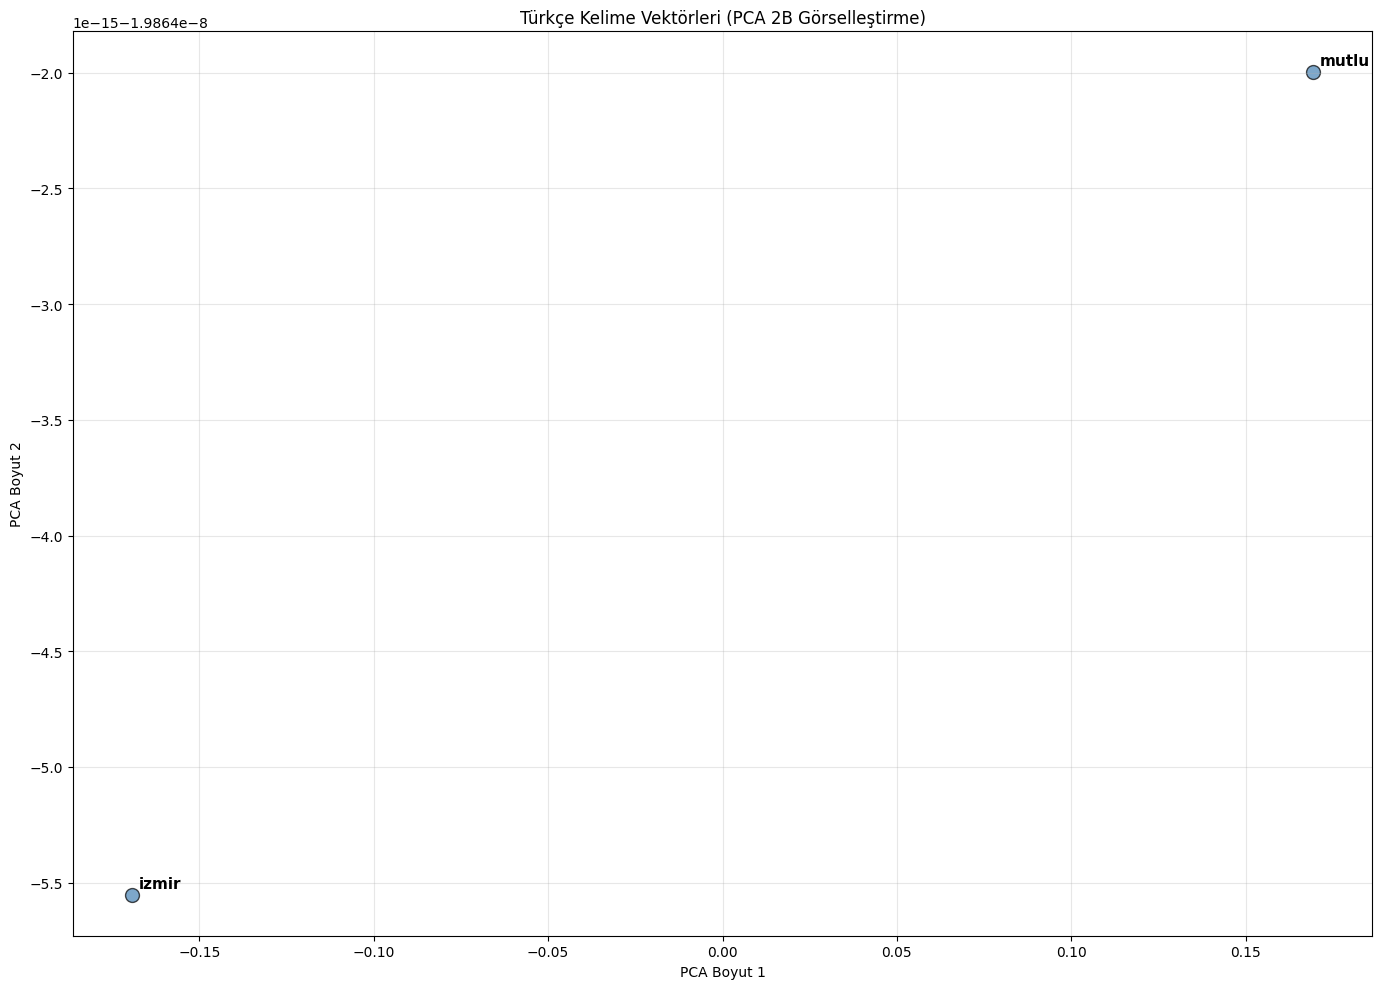

In [12]:
# PCA ile 2B görselleştirme
# Belirli kelimeleri seç
viz_words = [
    'güzel', 'çirkin', 'iyi', 'kötü', 'büyük', 'küçük',
    'istanbul', 'ankara', 'izmir', 'türkiye',
    'sevgi', 'nefret', 'mutlu', 'üzgün',
    'elma', 'armut', 'portakal',
    'kedi', 'köpek', 'hayvan'
]

# Mevcut kelimeleri filtrele
viz_words = [w for w in viz_words if w in sg_model.wv]
print(f'Görselleştirme için {len(viz_words)} kelime seçildi')

# Vektörleri al
word_vectors = np.array([sg_model.wv[w] for w in viz_words])

# PCA ile 2B'ye indir
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(word_vectors)

# Görselleştir
plt.figure(figsize=(14, 10))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='steelblue', s=100, alpha=0.7, edgecolors='black')

for i, word in enumerate(viz_words):
    plt.annotate(word,
                xy=(vectors_2d[i, 0], vectors_2d[i, 1]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.xlabel('PCA Boyut 1')
plt.ylabel('PCA Boyut 2')
plt.title('Türkçe Kelime Vektörleri (PCA 2B Görselleştirme)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

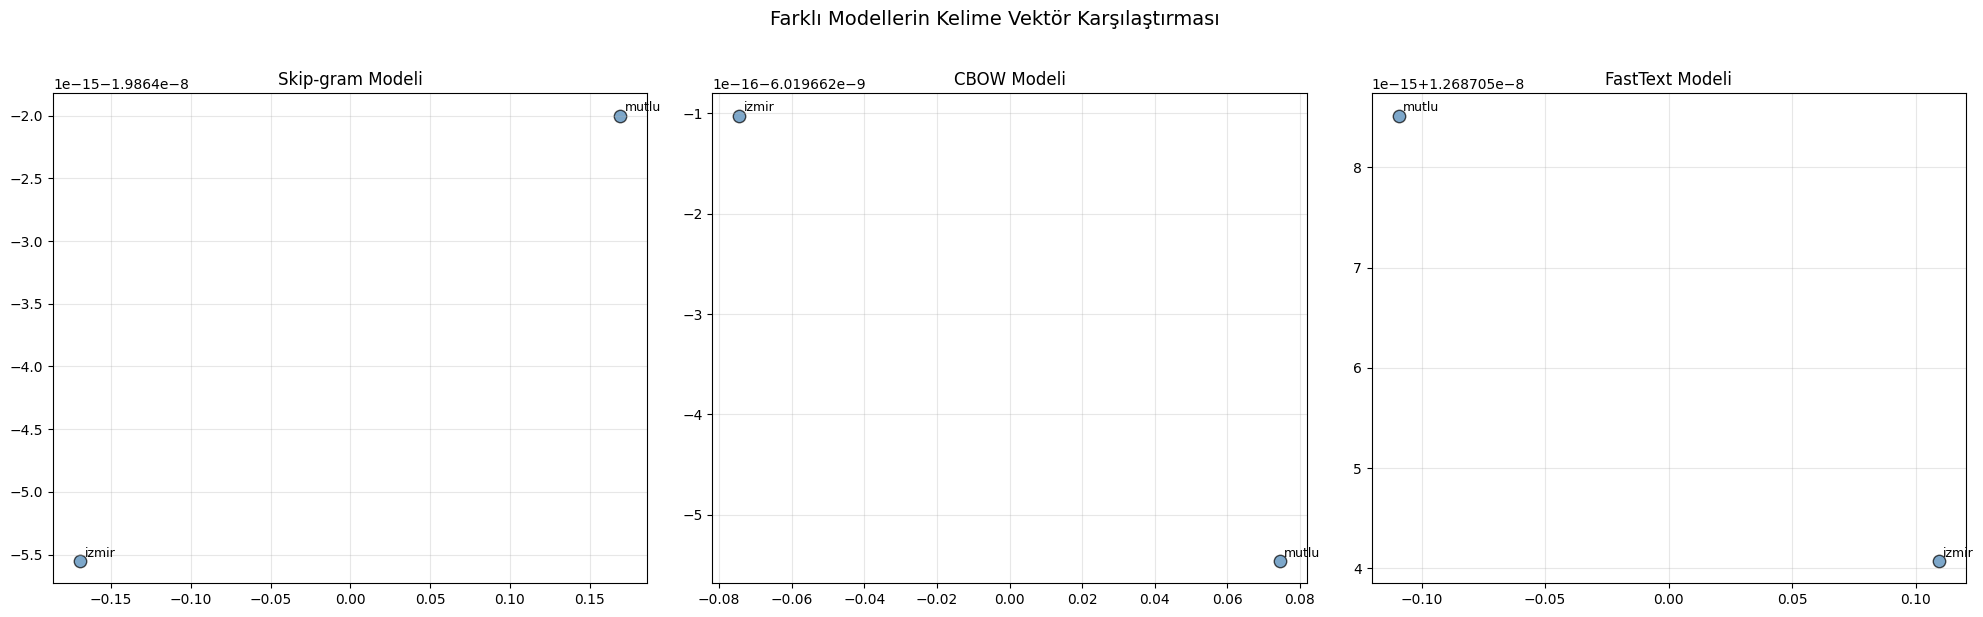

In [13]:
# Farklı model karşılaştırması
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models = {
    'Skip-gram': sg_model,
    'CBOW': cbow_model,
    'FastText': ft_model
}

for ax, (name, model) in zip(axes, models.items()):
    # Vektörleri al
    available_words = [w for w in viz_words if w in model.wv]
    vectors = np.array([model.wv[w] for w in available_words])

    # PCA
    pca = PCA(n_components=2)
    vec_2d = pca.fit_transform(vectors)

    ax.scatter(vec_2d[:, 0], vec_2d[:, 1], c='steelblue', s=80, alpha=0.7, edgecolors='black')
    for i, word in enumerate(available_words):
        ax.annotate(word, xy=(vec_2d[i, 0], vec_2d[i, 1]),
                   xytext=(3, 3), textcoords='offset points', fontsize=9)
    ax.set_title(f'{name} Modeli')
    ax.grid(True, alpha=0.3)

plt.suptitle('Farklı Modellerin Kelime Vektör Karşılaştırması', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 7. Benzerlik Matrisi

Seçili kelimeler arasındaki kosinüs benzerliğini ısı haritası ile görselleştireceğiz.

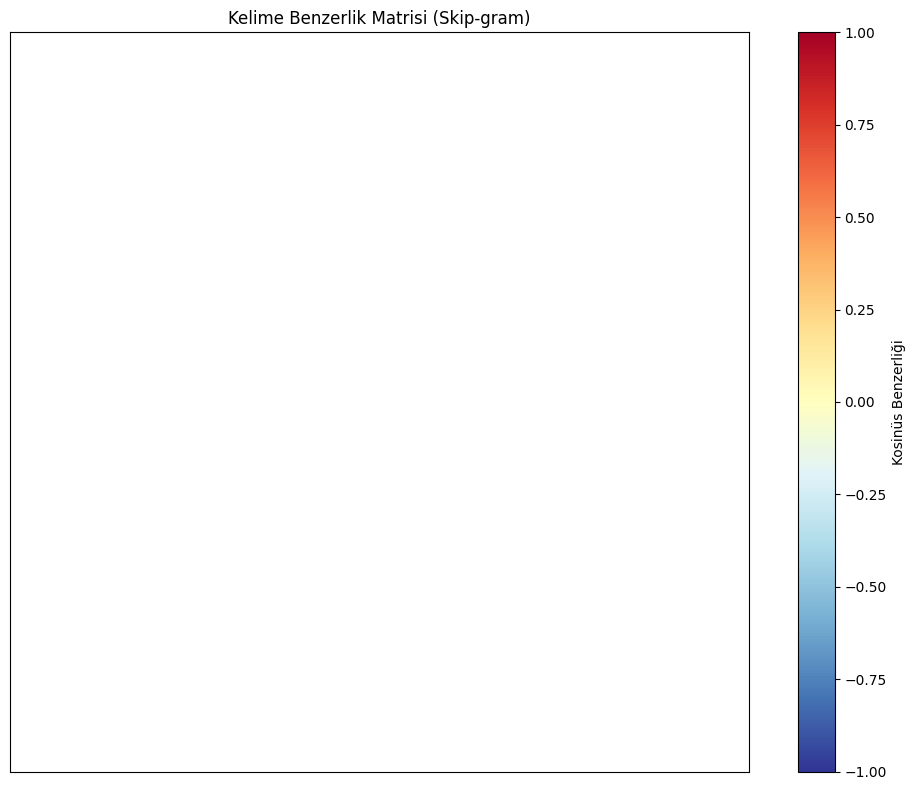

In [14]:
# Benzerlik matrisi (Skip-gram)
sim_words = ['güzel', 'kötü', 'sevgi', 'nefret', 'istanbul', 'ankara']
sim_words = [w for w in sim_words if w in sg_model.wv]

# Benzerlik matrisini hesapla
n = len(sim_words)
sim_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = sg_model.wv.similarity(sim_words[i], sim_words[j])

# Isı haritası
plt.figure(figsize=(10, 8))
plt.imshow(sim_matrix, cmap='RdYlBu_r', vmin=-1, vmax=1)
plt.colorbar(label='Kosinüs Benzerliği')
plt.xticks(range(n), sim_words, rotation=45, ha='right')
plt.yticks(range(n), sim_words)
plt.title('Kelime Benzerlik Matrisi (Skip-gram)')

# Değerleri yazdır
for i in range(n):
    for j in range(n):
        color = 'white' if sim_matrix[i, j] < 0.5 else 'black'
        plt.text(j, i, f'{sim_matrix[i, j]:.2f}', ha='center', va='center',
                color=color, fontsize=10)

plt.tight_layout()
plt.show()

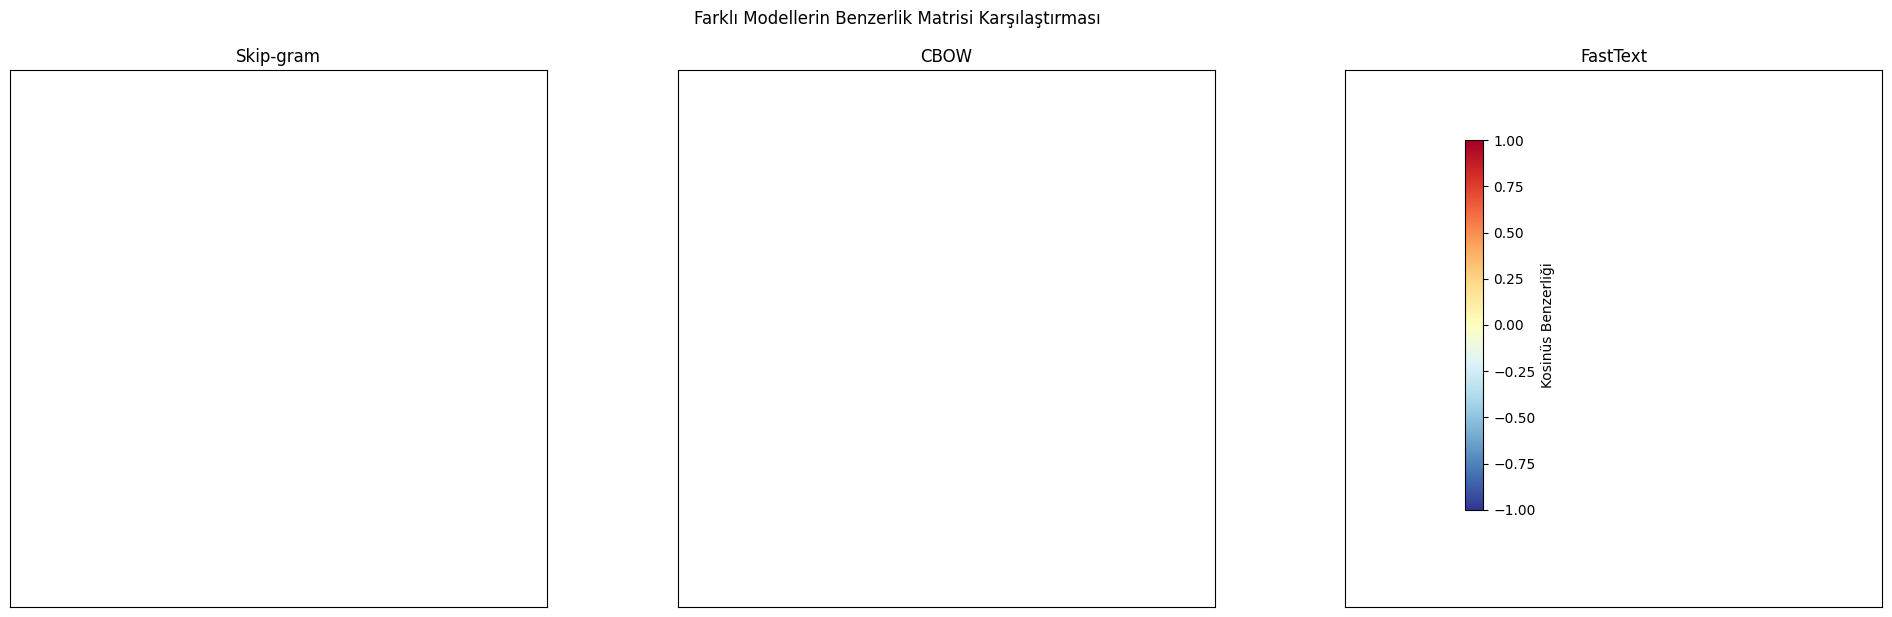

In [15]:
# Farklı modellerin benzerlik matrisi karşılaştırması
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, model) in zip(axes, models.items()):
    available = [w for w in sim_words if w in model.wv]
    n = len(available)
    mat = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            mat[i, j] = model.wv.similarity(available[i], available[j])

    im = ax.imshow(mat, cmap='RdYlBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(n))
    ax.set_xticklabels(available, rotation=45, ha='right')
    ax.set_yticks(range(n))
    ax.set_yticklabels(available)
    ax.set_title(f'{name}')

    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center', fontsize=8)

plt.suptitle('Farklı Modellerin Benzerlik Matrisi Karşılaştırması', y=1.02)
plt.colorbar(im, ax=axes, label='Kosinüs Benzerliği', shrink=0.8)
plt.tight_layout()
plt.show()

## 8. Sonuç Karşılaştırması

### Model Karşılaştırması

| Özellik | Word2Vec (Skip-gram) | Word2Vec (CBOW) | FastText |
|---------|---------------------|-----------------|----------|
| **Hız** | Yavaş | Hızlı | Orta |
| **Sıklık** | Nadir kelimeleri iyi öğrenir | Sık kelimeleri iyi öğrenir | Alt kelime bilgisi |
| **OOV** | Desteklemez | Desteklemez | Destekler (subword) |
| **Gürültü** | Duyarlı | Daha az duyarlı | Gürültüye dayanıklı |
| **Bellek** | Yüksek | Yüksek | Yüksek |

### Türkçe İçin Öneriler
- **FastText** Türkçe için en uygunudur (ekçekimli dil)
- Yeterli veri varsa Skip-gram genellikle daha iyi sonuç verir
- Vektör boyutu 100-300 arası önerilir
- minimum count = 5-10 arası tercih edilir

In [16]:
# Final karşılaştırma
print('=== Final Karşılaştırma ===')
print(f'{"Özellik":<25} {"Skip-gram":<15} {"CBOW":<15} {"FastText":<15}')
print('-' * 70)
print(f'{"Kelime Sayısı":<25} {len(sg_model.wv):<15} {len(cbow_model.wv):<15} {len(ft_model.wv):<15}')
print(f'{"Vektör Boyutu":<25} {sg_model.wv.vector_size:<15} {cbow_model.wv.vector_size:<15} {ft_model.wv.vector_size:<15}')
print(f'{"OOV Desteği":<25} {"Hayır":<15} {"Hayır":<15} {"Evet":<15}')
print(f'{"Eğitim Süresi":<25} {"Orta":<15} {"Hızlı":<15} {"Yavaş":<15}')
print(f'{"Alt Kelime":<25} {"Hayır":<15} {"Hayır":<15} {"Evet":<15}')

# Örnek benzerlik karşılaştırması
print(f'\n=== Örnek Benzerlik Karşılaştırması ===')
test_pairs = [('güzel', 'hoş'), ('sevgi', 'aşk'), ('istanbul', 'ankara')]

for w1, w2 in test_pairs:
    if w1 in sg_model.wv and w2 in sg_model.wv:
        sg = sg_model.wv.similarity(w1, w2)
        cbow = cbow_model.wv.similarity(w1, w2)
        ft = ft_model.wv.similarity(w1, w2)
        print(f'{w1}:{w2} -> SG={sg:.4f}, CBOW={cbow:.4f}, FT={ft:.4f}')

=== Final Karşılaştırma ===
Özellik                   Skip-gram       CBOW            FastText       
----------------------------------------------------------------------
Kelime Sayısı             217             217             217            
Vektör Boyutu             100             100             100            
OOV Desteği               Hayır           Hayır           Evet           
Eğitim Süresi             Orta            Hızlı           Yavaş          
Alt Kelime                Hayır           Hayır           Evet           

=== Örnek Benzerlik Karşılaştırması ===
